<a href="https://colab.research.google.com/github/RamadaniOktavia/ImageProcessing_2311533002/blob/main/Pertemuan%204/Tugas_Pertemuan_4_Image_Processing_2311533002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Bagian ini mengimpor pustaka yang diizinkan. cv2 digunakan secara eksklusif hanya untuk membaca file citra dari direktori. Pustaka numpy berperan penting sebagai alat komputasi matriks untuk mengelola nilai piksel citra tanpa bergantung pada fungsi instan pengolahan citra. Terakhir, matplotlib.pyplot digunakan untuk merender visualisasi citra dan grafik histogram pada hasil akhir.

# 2. Fungsi-Fungsi Dasar

a. Perhitungan Histogram Asli

In [10]:
def hitung_histogram(image):
    """Menghitung frekuensi kemunculan setiap nilai keabuan."""
    hist = np.zeros(256, dtype=int)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            hist[image[i, j]] += 1
    return hist

Fungsi ini bertugas menghitung frekuensi kemunculan setiap nilai keabuan dengan cara menghitung jumlah piksel yang mempunyai nilai keabuan tersebut. Program menyiapkan array kosong berisi 256 elemen (mewakili intensitas 0-255). Melalui perulangan bersarang, setiap piksel pada citra dipindai, dan nilai intensitasnya digunakan sebagai indeks pada array untuk ditambahkan nilainya sebanyak 1. Hasil akhirnya adalah $n_{i}$, yaitu jumlah piksel yang memiliki derajat keabuan tertentu.

b. Normalisasi Histogram

In [11]:
def normalisasi_histogram(hist, total_pixel):
    """
    Normalisasi histogram menggunakan rumus hi = ni / n.
    """
    return hist / total_pixel

Fungsi ini mengubah histogram frekuensi kemunculan menjadi probabilitas menggunakan rumus normalisasi histogram $h_{i}=\frac{n_{i}}{n}$. Operasi ini membagi array hasil fungsi sebelumnya ($n_{i}$) dengan total keseluruhan piksel di dalam citra ($n$). Hasil normalisasi ini menghasilkan nilai $h_{i}$ yang selalu berada di dalam selang 0 sampai 1.

c. Histogram Equalization

In [12]:
def histogram_equalization(image, hist_norm):
    """
    Melakukan equalization berdasarkan peluang kumulatif (CDF).
    """
    # 1. Menghitung probabilitas kumulatif (CDF)
    cdf = np.zeros(256, dtype=float)
    cdf[0] = hist_norm[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist_norm[i]

    # 2. Pemetaan nilai keabuan baru (CDF * L-1)
    # Maksimal nilai keabuan L-1 adalah 255
    transform_map = np.round(cdf * 255).astype(np.uint8)

    # 3. Menerapkan pemetaan ke citra hasil
    rows, cols = image.shape
    equalized_image = np.zeros((rows, cols), dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            equalized_image[i, j] = transform_map[image[i, j]]

    return equalized_image

Fungsi ini merupakan inti untuk mengubah distribusi gray level pada citra agar kontrasnya lebih menyebar pada kisaran 0-255. Prosesnya mencakup tiga langkah utama:

* Menghitung Cumulative Distribution Function (CDF) dengan mengakumulasikan nilai probabilitas dari histogram yang sudah dinormalisasi.

* Membangun peta transformasi dengan mengalikan array CDF dengan batas maksimal keabuan (255), membulatkannya, dan mengubahnya ke tipe data uint8.

* Memetakan ulang piksel pada citra. Program membuat matriks kosong seukuran citra asli, lalu mengganti nilai intensitas piksel lama dengan intensitas baru berdasarkan peta transformasi yang telah dibuat.

# 3. Program Utama

In [13]:
# Membaca citra (Ganti 'gambar.jpg' dengan file citra kamu)
# Kita baca dalam format grayscale
image = cv2.imread('imageIP.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Gambar tidak ditemukan!")
else:
    total_pixel = image.shape[0] * image.shape[1]

    # --- TUGAS 2: Normalisasi Histogram ---
    hist_asli = hitung_histogram(image)
    hist_norm = normalisasi_histogram(hist_asli, total_pixel)

    # --- TUGAS 3: Histogram Equalization setelah Normalisasi ---
    citra_eq = histogram_equalization(image, hist_norm)

    # Hitung kembali histogram citra hasil untuk divisualisasikan
    hist_eq = hitung_histogram(citra_eq)
    hist_norm_eq = normalisasi_histogram(hist_eq, total_pixel)

# 4. Visualisasi Hasil

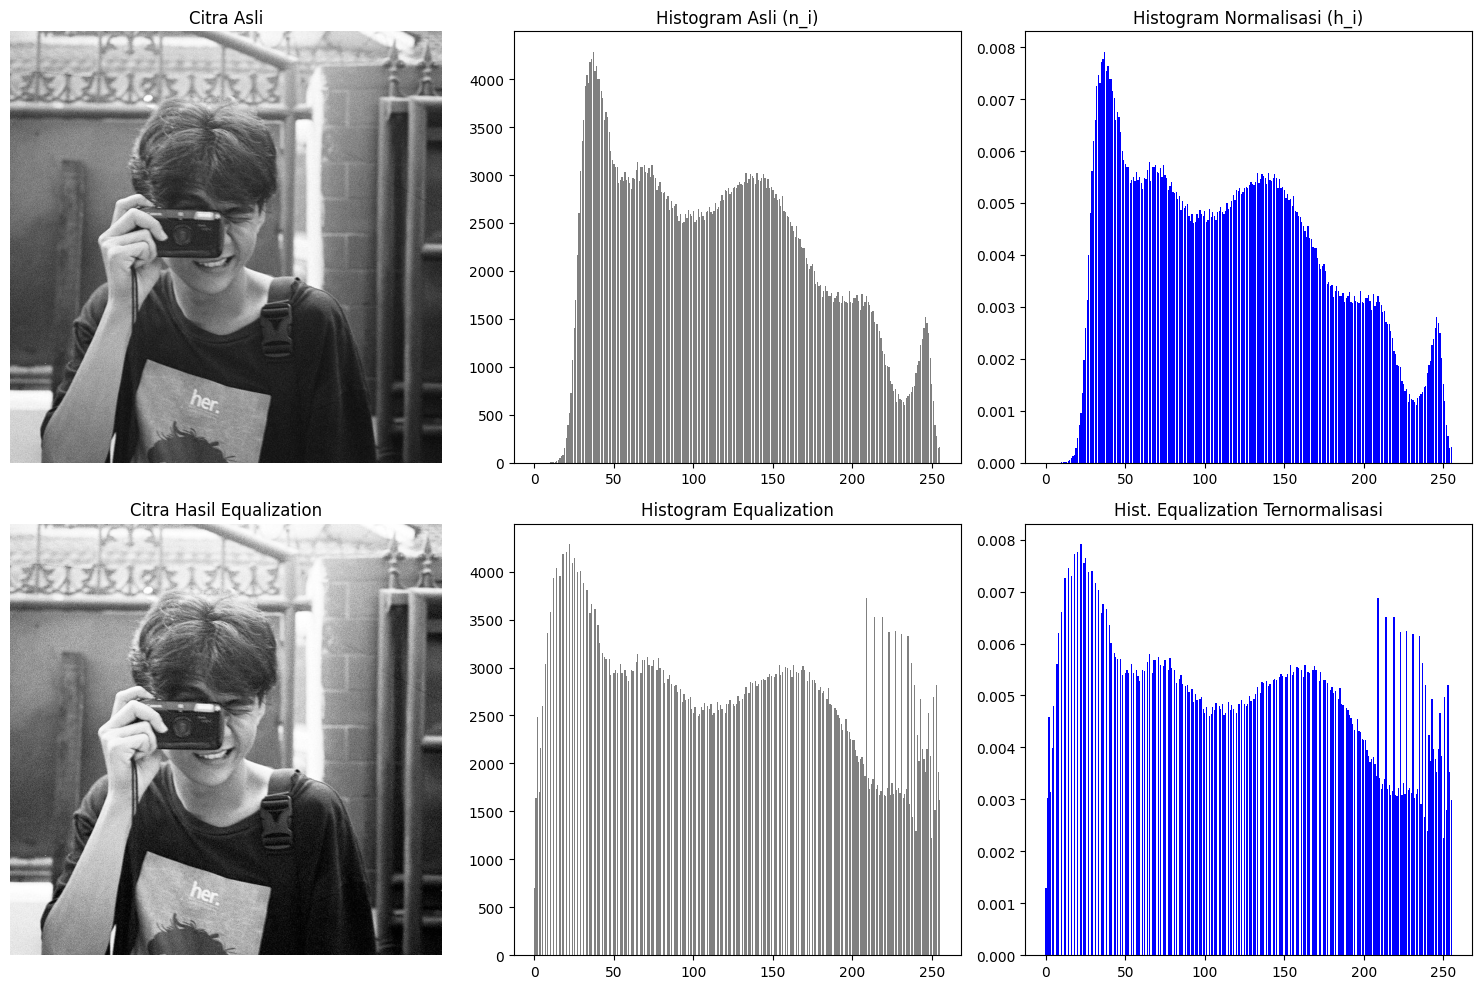

In [14]:
plt.figure(figsize=(15, 10))

# Baris 1: Citra Asli & Histogramnya
plt.subplot(2, 3, 1)
plt.title("Citra Asli")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Histogram Asli (n_i)")
plt.bar(range(256), hist_asli, color='gray')

plt.subplot(2, 3, 3)
plt.title("Histogram Normalisasi (h_i)")
plt.bar(range(256), hist_norm, color='blue')

# Baris 2: Citra Equalization & Histogramnya
plt.subplot(2, 3, 4)
plt.title("Citra Hasil Equalization")
plt.imshow(citra_eq, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Histogram Equalization")
plt.bar(range(256), hist_eq, color='gray')

plt.subplot(2, 3, 6)
plt.title("Hist. Equalization Ternormalisasi")
plt.bar(range(256), hist_norm_eq, color='blue')

plt.tight_layout()
plt.show()

Bagian ini adalah alur eksekusi (driver code). Gambar dibaca dalam format grayscale, kemudian program menghitung total piksel secara dinamis. Fungsi-fungsi pemrosesan (hitung_histogram, normalisasi_histogram, dan histogram_equalization) dipanggil secara berurutan. Setelah matriks citra baru terbentuk, program menggunakan fitur subplot dari matplotlib untuk menyandingkan citra asli beserta histogramnya dengan citra hasil equalization beserta histogramnya untuk kebutuhan perbandingan di laporan.